# Simulation Visualization

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Add the parent directory to the path to import the simulation framework
sys.path.append(os.path.abspath('..'))

from simulation_framework import simulate_longitudinal_data, create_spike_effect

In [2]:
def plot_simulation(df, active_pathway_id, true_pathways, n_subjects_to_plot=5, n_metabolites_to_plot=5):
    """
    Plots a subset of the simulated longitudinal data.
    """
    active_metabolites = true_pathways[active_pathway_id]
    inactive_metabolites = [m for m in df['metabolite_id'].unique() if m not in active_metabolites]

    # Select a subset of subjects and metabolites to plot
    subjects_to_plot = df['subject_id'].unique()[:n_subjects_to_plot]
    active_metabolites_to_plot = active_metabolites[:n_metabolites_to_plot]
    inactive_metabolites_to_plot = inactive_metabolites[:n_metabolites_to_plot]

    plot_df = df[df['subject_id'].isin(subjects_to_plot) & 
                   (df['metabolite_id'].isin(active_metabolites_to_plot) | 
                    df['metabolite_id'].isin(inactive_metabolites_to_plot))]

    # Add a column to indicate if a metabolite is in the active pathway
    plot_df['active_pathway'] = plot_df['metabolite_id'].isin(active_metabolites)

    # Create the plot
    g = sns.FacetGrid(plot_df, col="metabolite_id", hue="subject_id", col_wrap=5, sharey=False)
    g.map(sns.lineplot, "time", "value", marker="o")
    g.add_legend()
    g.fig.suptitle('Simulated Metabolomics Data', y=1.03)
    plt.show()


In [3]:
# --- 1. Configure and Run Simulation ---
# Define the temporal effect we want to test
spike_func = create_spike_effect(time_start=8, time_end=12, magnitude=2.5)

df, true_pathways, annotated_pathways = simulate_longitudinal_data(
    n_subjects=5,
    n_metabolites=100,
    n_pathways=5,
    metabolites_per_pathway=20,
    effect_func=spike_func,
    active_pathway_idx=0,  # The first pathway will have the spike
    time_points=np.linspace(0, 20, 50)
)
print(f"{df=}")
print(f"{true_pathways=}")
print(f"{annotated_pathways=}")

df=      subject_id metabolite_id       time  value   true_mu  is_active
0            S_1          M001   0.000000      3  1.360850          1
1            S_1          M002   0.000000      2  1.165083          1
2            S_1          M003   0.000000      2  1.615265          1
3            S_1          M004   0.000000      0  0.567624          1
4            S_1          M005   0.000000      3  3.134348          1
...          ...           ...        ...    ...       ...        ...
24995        S_5          M096  23.126801      0  0.820565          0
24996        S_5          M097  23.126801      2  1.446214          0
24997        S_5          M098  23.126801      2  1.170450          0
24998        S_5          M099  23.126801      0  0.982134          0
24999        S_5          M100  23.126801      0  0.633767          0

[25000 rows x 6 columns]
true_pathways={'Pathway_1': ['M001', 'M002', 'M003', 'M004', 'M005', 'M006', 'M007', 'M008', 'M009', 'M010', 'M011', 'M012', 'M013'

/var/folders/2w/r7x976td4f97twg4r5ff50500000gn/T/ipykernel_26359/2598476689.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['active_pathway'] = plot_df['metabolite_id'].isin(active_metabolites)


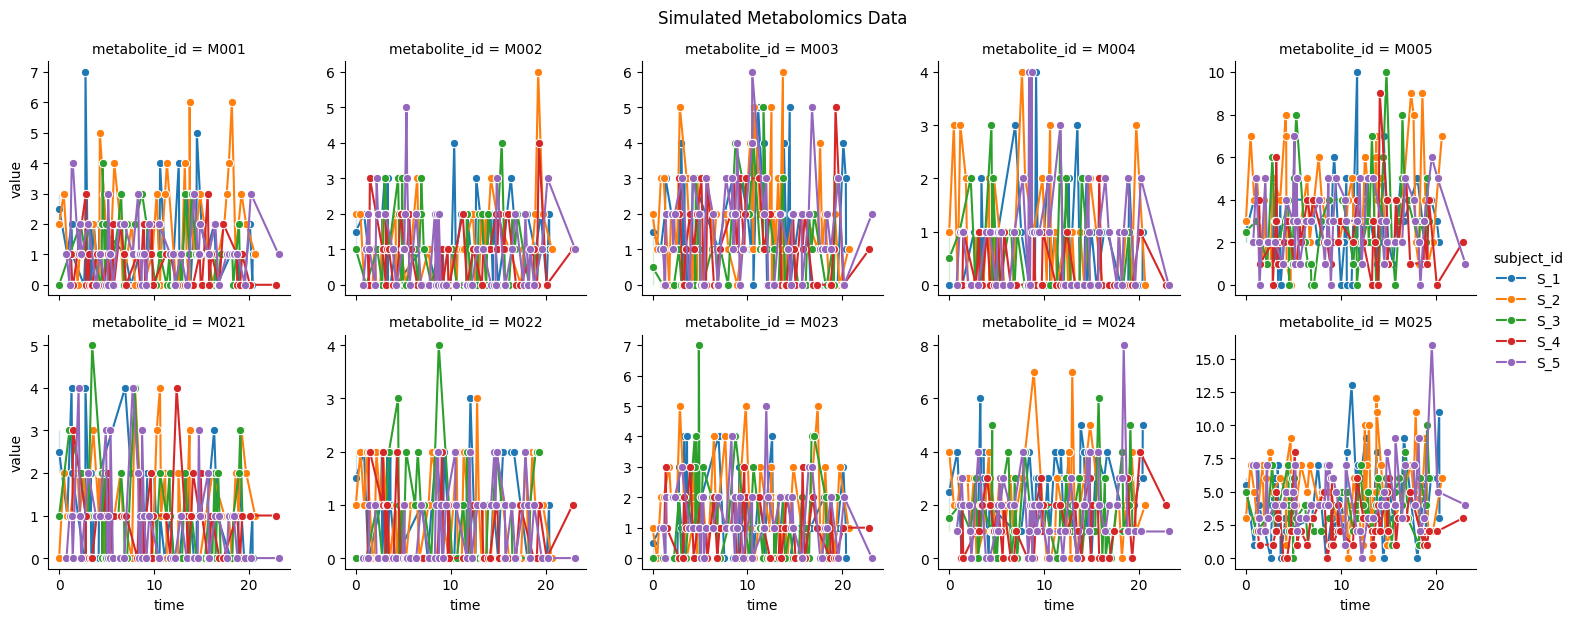

In [4]:
# --- 2. Plot the results ---
active_pathway_id = list(true_pathways.keys())[0]
plot_simulation(df, active_pathway_id, true_pathways)